<a href="https://colab.research.google.com/github/BhuvanHande/ALA/blob/main/overfi_underfittest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mariolisboa/breast-cancer-wisconsin-original-data-set")

print("Path to dataset files:", path)

100%|██████████| 5.93k/5.93k [00:00<00:00, 6.77MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mariolisboa/breast-cancer-wisconsin-original-data-set/versions/1


In [ ]:
import os

print(os.listdir(path))



['breast_cancer_bd.csv']


In [ ]:
import pandas as pd
import os

file_path = os.path.join(path, "breast_cancer_bd.csv")

df = pd.read_csv(file_path)

print(df.head())
print(df.shape)

   Sample code number  Clump Thickness  Uniformity of Cell Size  \
0             1000025                5                        1   
1             1002945                5                        4   
2             1015425                3                        1   
3             1016277                6                        8   
4             1017023                4                        1   

   Uniformity of Cell Shape  Marginal Adhesion  Single Epithelial Cell Size  \
0                         1                  1                            2   
1                         4                  5                            7   
2                         1                  1                            2   
3                         8                  1                            3   
4                         1                  3                            2   

  Bare Nuclei  Bland Chromatin  Normal Nucleoli  Mitoses  Class  
0           1                3                1        1

In [ ]:
columns = [
    "id",
    "clump_thickness",
    "uniformity_cell_size",
    "uniformity_cell_shape",
    "marginal_adhesion",
    "single_epithelial_cell_size",
    "bare_nuclei",
    "bland_chromatin",
    "normal_nucleoli",
    "mitoses",
    "diagnosis"
]

df.columns = columns

print(df.head())


        id  clump_thickness  uniformity_cell_size  uniformity_cell_shape  \
0  1000025                5                     1                      1   
1  1002945                5                     4                      4   
2  1015425                3                     1                      1   
3  1016277                6                     8                      8   
4  1017023                4                     1                      1   

   marginal_adhesion  single_epithelial_cell_size bare_nuclei  \
0                  1                            2           1   
1                  5                            7          10   
2                  1                            2           2   
3                  1                            3           4   
4                  3                            2           1   

   bland_chromatin  normal_nucleoli  mitoses  diagnosis  
0                3                1        1          2  
1                3                2 

In [ ]:
df = df.replace("?", pd.NA)

df = df.dropna()

# Convert columns to numbers
for column in df.columns:
    df[column] = pd.to_numeric(df[column])


In [ ]:
X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (683, 9)
y shape: (683,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (546, 9)
Testing data: (137, 9)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

# Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Accuracy
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print("Difference:", train_accuracy - test_accuracy)


Training Accuracy: 0.9871794871794872
Testing Accuracy: 0.9562043795620438
Difference: 0.030975107617443376


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy:", accuracy_score(y_test, test_pred))


Training Accuracy: 0.9871794871794872
Testing Accuracy: 0.9562043795620438


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

for depth in [1, 2, 3, 4, 5, 6, 7, 8, 10, 12]:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_acc = accuracy_score(
        y_train,
        model.predict(X_train)
    )

    test_acc = accuracy_score(
        y_test,
        model.predict(X_test)
    )

    print(
        f"Depth: {depth:2d} | "
        f"Training: {train_acc:.4f} | "
        f"Testing: {test_acc:.4f} | "
        f"Gap: {train_acc-test_acc:.4f}"
    )


Depth:  1 | Training: 0.9322 | Testing: 0.8978 | Gap: 0.0344
Depth:  2 | Training: 0.9615 | Testing: 0.9416 | Gap: 0.0199
Depth:  3 | Training: 0.9652 | Testing: 0.9562 | Gap: 0.0090
Depth:  4 | Training: 0.9725 | Testing: 0.9489 | Gap: 0.0236
Depth:  5 | Training: 0.9872 | Testing: 0.9562 | Gap: 0.0310
Depth:  6 | Training: 0.9963 | Testing: 0.9562 | Gap: 0.0401
Depth:  7 | Training: 1.0000 | Testing: 0.9489 | Gap: 0.0511
Depth:  8 | Training: 1.0000 | Testing: 0.9489 | Gap: 0.0511
Depth: 10 | Training: 1.0000 | Testing: 0.9489 | Gap: 0.0511
Depth: 12 | Training: 1.0000 | Testing: 0.9489 | Gap: 0.0511


In [ ]:
model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_leaf_nodes=20,
    random_state=42
)

model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, max_leaf_nodes=20, min_samples_leaf=5,
                       min_samples_split=10, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

print(y_pred)


[2 2 2 2 2 4 2 2 4 2 4 2 2 4 4 2 2 4 2 4 2 4 4 2 2 2 4 2 2 2 2 4 2 4 2 2 4
 2 2 4 4 4 2 2 2 2 4 4 4 2 4 2 2 4 2 2 4 2 2 2 2 4 2 2 4 4 2 2 2 2 2 2 4 2
 2 2 4 2 2 4 2 2 2 2 4 2 2 2 4 2 4 2 2 2 2 2 2 2 4 4 2 2 4 2 2 2 4 4 2 4 4
 2 2 4 4 4 4 2 4 4 4 4 2 2 4 2 4 2 2 2 2 2 4 2 2 2 4]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")


Accuracy: 0.9562043795620438
Accuracy percentage: 95.62043795620438 %


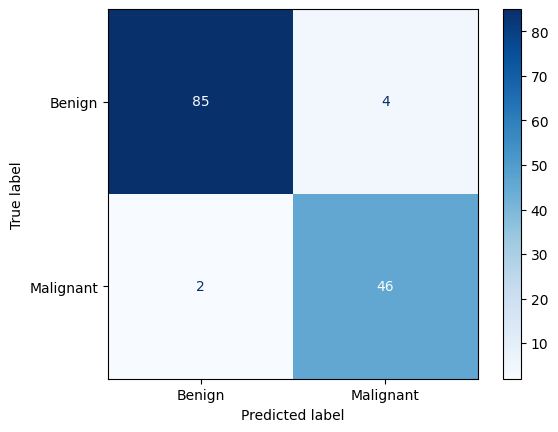

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot(cmap="Blues")


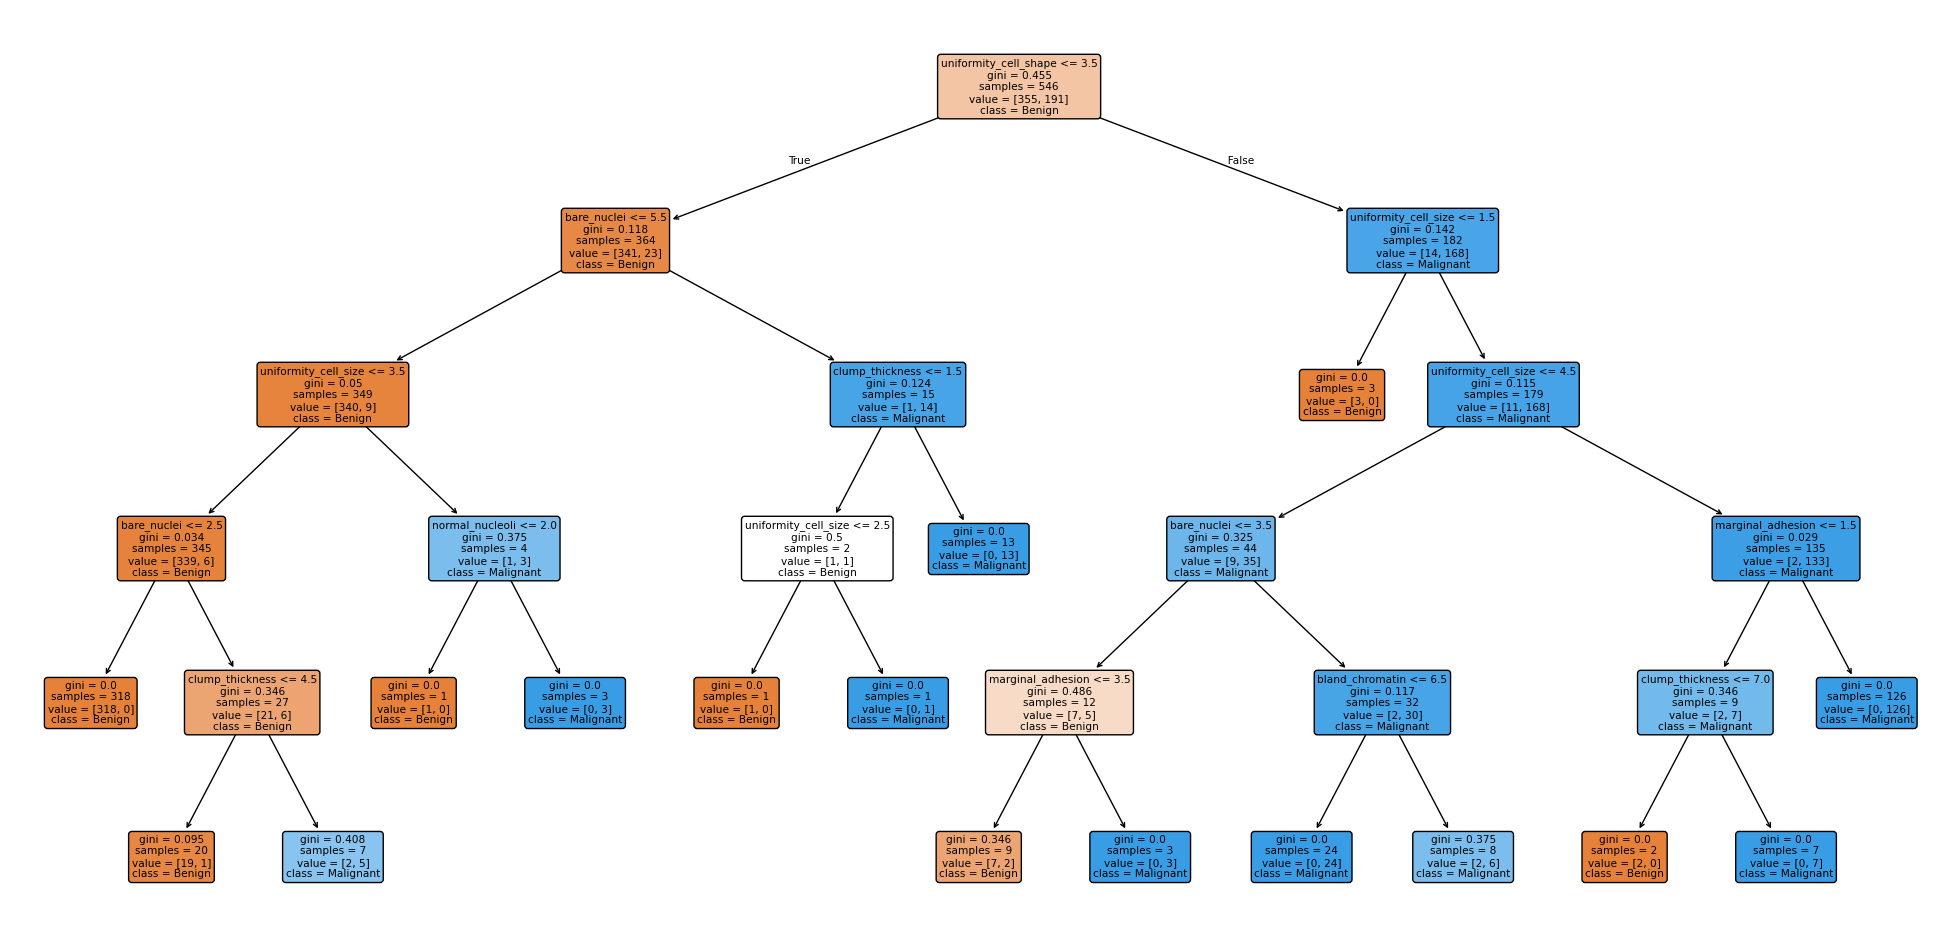

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 12))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Benign", "Malignant"],
    filled=True,
    rounded=True
)

plt.show()
